#Forward Propagation

## Import libraries



In [3]:
!pip install numpy matplotlib scikit-learn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 15.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 12.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 10.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 11.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 13.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.4/20.4 MB 12.8 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13/13 [matplotlib]3 [matplotlib]n]


Matplotlib is building the font cache; this may take a moment.


## Define activation functions


In [4]:
def relu(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def softmax(z):
    # Numerically stable softmax
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)


## Load & Prepare Wine Dataset

Dataset properties:
- 178 samples
- 13 input features per sample
- 3 output classes

X - input features  
y - class labels

This dataset is used only to demonstrate how forward propagation works on real data.






In [5]:
wine = load_wine()

X = wine.data        # shape: (178, 13)
y = wine.target      # 3 classes: 0,1,2

print("Input shape:", X.shape)
print("Target shape:", y.shape)


Input shape: (178, 13)
Target shape: (178,)


### Standardize features

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Train–Test Split



In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Test samples     :", X_test.shape[0])


Training samples: 142
Test samples     : 36



## Neural Network Architecture



In [8]:
input_neurons = 13
hidden_neurons = 8
output_neurons = 3

print("Network Architecture")
print(f"Input  : {input_neurons}")
print(f"Hidden : {hidden_neurons}")
print(f"Output : {output_neurons}")


Network Architecture
Input  : 13
Hidden : 8
Output : 3


## Initialize weights and biases


In [9]:
# Initialize weights and biases
weights_input_hidden = np.random.randn(input_neurons, hidden_neurons)
biases_hidden = np.zeros((1, hidden_neurons))

weights_hidden_output = np.random.randn(hidden_neurons, output_neurons)
biases_output = np.zeros((1, output_neurons))

# Print shapes to verify
print("Shape of weights_input_hidden:", weights_input_hidden.shape)
print("Shape of biases_hidden:", biases_hidden.shape)
print("Shape of weights_hidden_output:", weights_hidden_output.shape)
print("Shape of biases_output:", biases_output.shape)

Shape of weights_input_hidden: (13, 8)
Shape of biases_hidden: (1, 8)
Shape of weights_hidden_output: (8, 3)
Shape of biases_output: (1, 3)


## Implement forward propagation

In [10]:
def forward_propagation(X, W1, b1, W2, b2):
    # Hidden layer
    z1 = np.dot(X, W1) + b1
    a1 = relu(z1)

    # Output layer
    z2 = np.dot(a1, W2) + b2
    a2 = softmax(z2)   # element-wise, for demo

    return z1, a1, z2, a2

## Run Forward Propogation on one wine sample

In [11]:
sample_index = 0
sample_input = X_train[sample_index].reshape(1, -1)

z1, a1, z2, output = forward_propagation(
    sample_input,
    weights_input_hidden,
    biases_hidden,
    weights_hidden_output,
    biases_output
)

print("\nHidden Layer Output (Before ReLU):")
print(z1)

print("\nHidden Layer Output (After ReLU):")
print(a1)

print("\nOutput Layer (After Softmax):")
print(output)
print("Sum of probabilities:", np.sum(output))



Hidden Layer Output (Before ReLU):
[[ 2.4218684   3.43661254  3.80134298  0.94429446 -2.23391386  2.35259808
   3.46364117  2.92957757]]

Hidden Layer Output (After ReLU):
[[2.4218684  3.43661254 3.80134298 0.94429446 0.         2.35259808
  3.46364117 2.92957757]]

Output Layer (After Softmax):
[[9.97983389e-01 2.01661073e-03 3.27459626e-11]]
Sum of probabilities: 0.9999999999999999


In [12]:
predicted_class = np.argmax(output)
true_class = y_train[sample_index]

print("\nPredicted Class:", predicted_class)
print("True Class     :", true_class)


Predicted Class: 0
True Class     : 0


## Visualization: Actual vs Predicted Classes




In [13]:
num_samples = X_train.shape[0]
actual_classes = y_train

# Run forward propagation for all training samples to get predicted classes
_, _, _, probabilities = forward_propagation(
    X_train,
    weights_input_hidden,
    biases_hidden,
    weights_hidden_output,
    biases_output
)
predicted_classes = np.argmax(probabilities, axis=1)

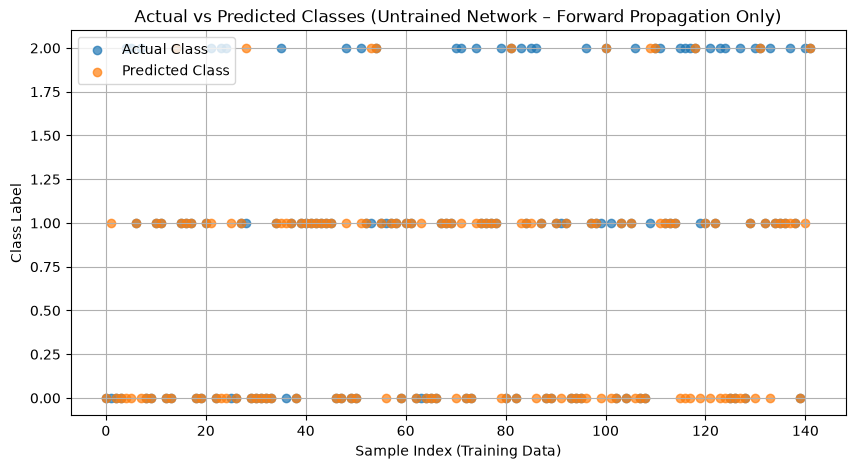

In [15]:
plt.figure(figsize=(10, 5))

plt.scatter(range(num_samples), actual_classes,
            label="Actual Class", alpha=0.7)

plt.scatter(range(num_samples), predicted_classes,
            label="Predicted Class", alpha=0.7)

plt.xlabel("Sample Index (Training Data)")
plt.ylabel("Class Label")
plt.title("Actual vs Predicted Classes (Untrained Network – Forward Propagation Only)")
plt.legend()
plt.grid(True)

plt.show()

In [17]:
def one_hot_encode(y, num_classes):
    one_hot = np.zeros((y.shape[0], num_classes))
    one_hot[np.arange(y.shape[0]), y] = 1
    return one_hot

y_train_one_hot = one_hot_encode(y_train, output_neurons)


In [21]:
def cross_entropy_loss(y_true, y_pred):
    epsilon = 1e-9
    y_pred = np.clip(y_pred, epsilon , 1 - epsilon)
    loss = -np.sum(y_true * np.log(y_pred), axis=1)
    return np.mean(loss)

In [22]:
y_true_sample = y_train_one_hot[sample_index].reshape(1,-1)
y_pred_sample = output 
loss_sample = cross_entropy_loss(y_true_sample, y_pred_sample)
print("Loss for a single sample:", loss_sample)

Loss for a single sample: 0.0020186468560738726
